### References:
* https://github.com/aws/amazon-sagemaker-examples/blob/main/sagemaker-python-sdk/scikit_learn_iris/scikit_learn_estimator_example_with_batch_transform.ipynb

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score
                             )
import matplotlib.pyplot as plt
import seaborn as sns

### Set the Client

In [2]:
import boto3
import sagemaker
from sagemaker import get_execution_role
# S3 prefix
prefix = "Churn-Prediction"

region = "eu-west-1"
boto_session = boto3.Session(region_name=region)
sagemaker_session = sagemaker.Session(boto_session=boto_session)
role = get_execution_role()

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:172: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[05/03/25 09:55:35] INFO     Found credentials from IAM Role:                                   ]8;id=325057;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=315629;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


[05/03/25 09:55:36] INFO     Found credentials from IAM Role:                                   ]8;id=930226;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=590229;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

                    INFO     Found credentials from IAM Role:                                   ]8;id=616256;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=92124;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

### Training

In [3]:
os.makedirs("./data", exist_ok=True)

DATA_BUCKET = 'customer-churn-training-ie'
TRAIN_DATA_PATH = 'data/Telco-Customer-Churn-cleaned-train.csv'
LOCAL_TRAIN_DATA_PATH = './data/chrun_train.csv'

s3_client = boto3.client("s3")
s3_client.download_file(
    DATA_BUCKET, TRAIN_DATA_PATH, LOCAL_TRAIN_DATA_PATH
)

df = pd.read_csv(LOCAL_TRAIN_DATA_PATH)

                    INFO     Found credentials from IAM Role:                                   ]8;id=788449;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=471314;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/credentials.py#1132\1132]8;;\
                             BaseNotebookInstanceEc2InstanceRole                                                   

In [4]:
WORK_DIRECTORY = "data"

train_input = sagemaker_session.upload_data(
    WORK_DIRECTORY, key_prefix="{}/{}".format(prefix, WORK_DIRECTORY)
)

In [5]:
SAGEMAKER_BUCKET_NAME = 'sagemaker-eu-west-1-838676815664'

In [ ]:
from sagemaker.sklearn.estimator import SKLearn

FRAMEWORK_VERSION = "1.2-1"
script_path = "entry_point.py"                  # under training/scripts/entry_point.py in GitHub Repo
learning_rate = 0.8595807276060273
n_estimators = 126

sklearn = SKLearn(
    entry_point=script_path,
    framework_version=FRAMEWORK_VERSION,
    instance_type="ml.m5.large",
    role=role,
    sagemaker_session=sagemaker_session,
    hyperparameters={'learning-rate': learning_rate, 'n-estimators': n_estimators}
)

In [7]:
sklearn.fit({"train": train_input})

[05/03/25 09:55:37] INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=897013;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=980857;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

                    INFO     Creating training-job with name:                                       ]8;id=680661;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=243569;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#1042\1042]8;;\
                             sagemaker-scikit-learn-2025-05-03-09-55-37-398                                        

2025-05-03 09:55:41 Starting - Starting the training job...
2025-05-03 09:55:55 Starting - Preparing the instances for training...
2025-05-03 09:56:41 Downloading - Downloading the training image........2025-05-03 09:57:47,922 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2025-05-03 09:57:47,924 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2025-05-03 09:57:47,927 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-05-03 09:57:47,943 sagemaker_sklearn_container.training INFO     Invoking user training script.
2025-05-03 09:57:48,187 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2025-05-03 09:57:48,191 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2025-05-03 09:57:48,211 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2025-05-03 09:57:48,214 sagemaker-train

### Deploy the model

In [8]:
predictor = sklearn.deploy(initial_instance_count=1, instance_type="ml.m5.large")

[05/03/25 09:58:24] INFO     Creating model with name:                                              ]8;id=988108;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=180165;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4094\4094]8;;\
                             sagemaker-scikit-learn-2025-05-03-09-58-24-051                                        

                    INFO     Creating endpoint-config with name                                     ]8;id=804695;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=971305;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#6019\6019]8;;\
                             sagemaker-scikit-learn-2025-05-03-09-58-24-051                                        

                    INFO     Creating endpoint with name                                            ]8;id=306973;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=765351;file:///home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/session.py#4841\4841]8;;\
                             sagemaker-scikit-learn-2025-05-03-09-58-24-051                                        

-----!

In [26]:
TEST_DATA_PATH = 'data/Telco-Customer-Churn-cleaned-test.csv'
TEMP_TEST_DATA_PATH = '/tmp/Telco-Customer-Churn-cleaned-test.csv'

s3_client.download_file(
    DATA_BUCKET, TEST_DATA_PATH, TEMP_TEST_DATA_PATH
)

test_df = pd.read_csv(TEMP_TEST_DATA_PATH)

In [44]:
X_test = test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

res = predictor.predict(X_test.to_csv(index=False))

In [46]:
arr = np.array(res)

# Directly extract the string from the 0-dimensional array
response_str = arr.item()

values = response_str.strip().split('\n')

if values[0].lower() == "prediction":
    values = values[1:]

int_values = list(map(int, values))

# Step 5: Convert to a pandas Series
y_pred = pd.Series(int_values)

In [61]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 0.5101
Recall: 0.7433
Accuracy: 0.7420


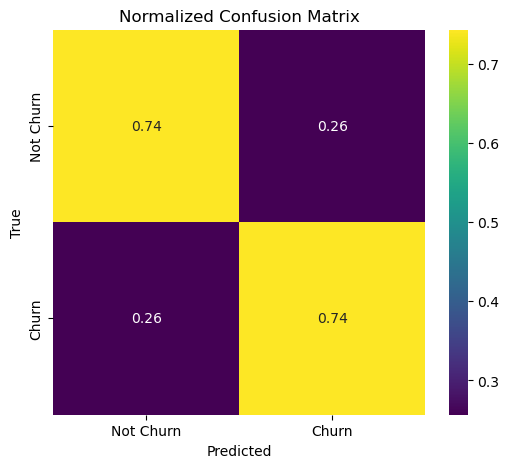

In [57]:
cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix')
plt.show()


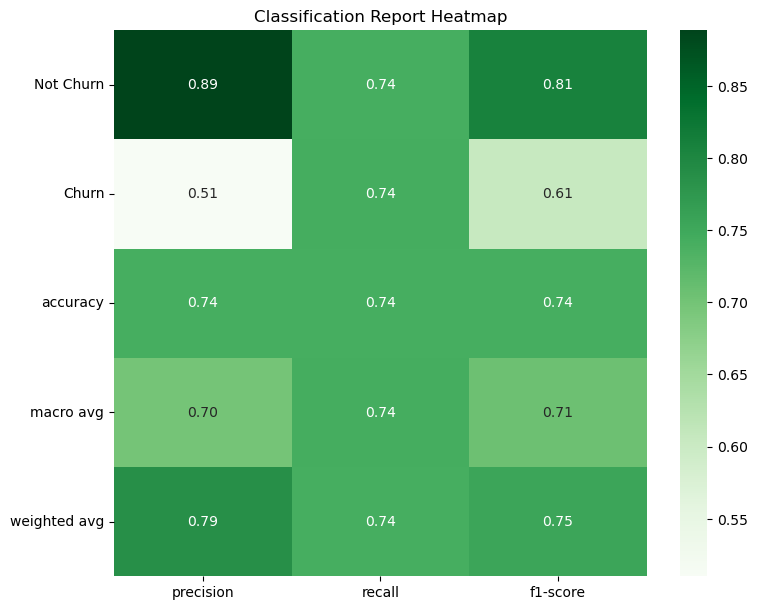

In [58]:
clf_report = classification_report(y_test, y_pred, labels = [0, 1],
                                   target_names=["Not Churn", "Churn"], output_dict=True
                                   )
report_df = pd.DataFrame(clf_report).iloc[:-1, :].T  # Excluding 'support'

plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True, fmt='.2f', cmap='Greens', cbar=True)

plt.yticks(rotation=0)
plt.tight_layout()
plt.title('Classification Report Heatmap')
plt.show()